# Import Packages

In [2]:
!pip install seaborn scikit-learn tqdm

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.8 MB 3.7 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/7.8 MB 3.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.4/7.8 MB 3.6 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/7.8 MB 3.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.1/7.8 MB 3.4 MB/s eta 0:00:02
   -------------------- ------------------- 3.9/7.8 MB 3.0 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/7.8 MB 3.1 MB/s eta 0:00:02
   ---------------------------- ----------- 5.5/7.8 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/7.8 MB 3.2 MB/s eta 0:00:0

In [3]:

import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm

In [4]:
class_names = ["Normal", "Stroke"]
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)

# Loading the Data
We have to write a load_data function that load the images and the labels from the folder.

In [5]:
def load_data():

    datasets = [r'train', r'test']

    output = []

    # Iterate through training and test sets
    for dataset in datasets:

        images = []
        labels = []

        print("Loading {}".format(dataset))

        # Iterate through each folder corresponding to a category
        for folder in os.listdir(dataset):
            label = class_names_label[folder]

            # Iterate through each image in our folder
            for file in tqdm(os.listdir(os.path.join(dataset, folder))):

                # Get the path name of the image
                img_path = os.path.join(os.path.join(dataset, folder), file)

                # Open and resize the img
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                # Append the image and its corresponding label to the output
                images.append(image)
                labels.append(label)

        images = np.array(images, dtype = 'float32')
        labels = np.array(labels, dtype = 'int32')

        output.append((images, labels))

    return output

In [6]:
(train_images, train_labels), (test_images, test_labels) = load_data()

Loading train


100%|████████████████████████████████████████████████████████████████████████████████| 950/950 [00:21<00:00, 44.65it/s]


Loading test


100%|████████████████████████████████████████████████████████████████████████████████| 655/655 [00:16<00:00, 39.93it/s]


In [7]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

In [8]:
n_train = train_labels.shape[0]
n_test = test_labels.shape[0]

print ("Number of training examples: {}".format(n_train))
print ("Number of testing examples: {}".format(n_test))
print ("Each image is of size: {}".format(IMAGE_SIZE))

Number of training examples: 2501
Number of testing examples: 1211
Each image is of size: (150, 150)


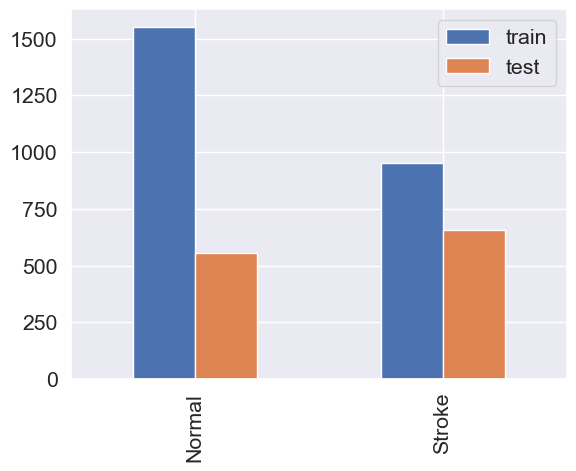

In [9]:
import pandas as pd

_, train_counts = np.unique(train_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)
pd.DataFrame({'train': train_counts,
                    'test': test_counts},
             index=class_names
            ).plot.bar()
plt.show()

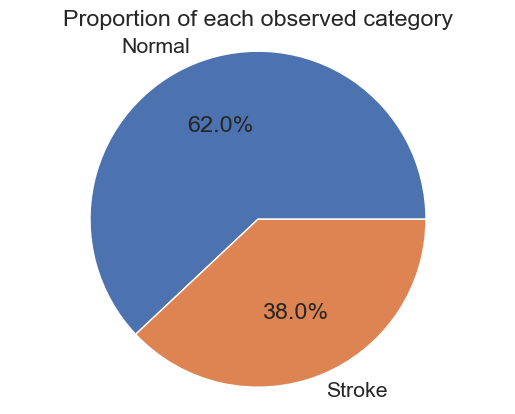

In [10]:
plt.pie(train_counts,
        explode=(0,0) ,
        labels=class_names,
        autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each observed category')
plt.show()

## Good practice: scale the data

In [11]:
train_images = train_images / 255.0
test_images = test_images / 255.0

## Visualize the data
We can display a random image from the training set.

In [12]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """

    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{} : '.format(index) + class_names[labels[index]])
    plt.show()

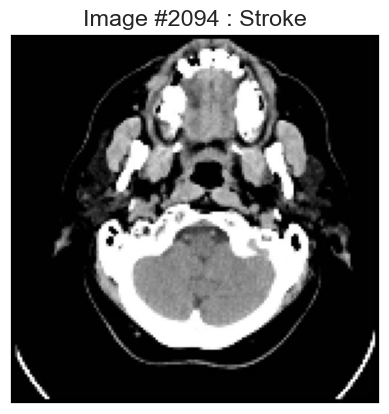

In [13]:
display_random_image(class_names, train_images, train_labels)

In [14]:
import matplotlib.pyplot as plt

def display_examples(class_names, images, labels):
    """
    Display 25 images from the images array with its corresponding labels
    """
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()


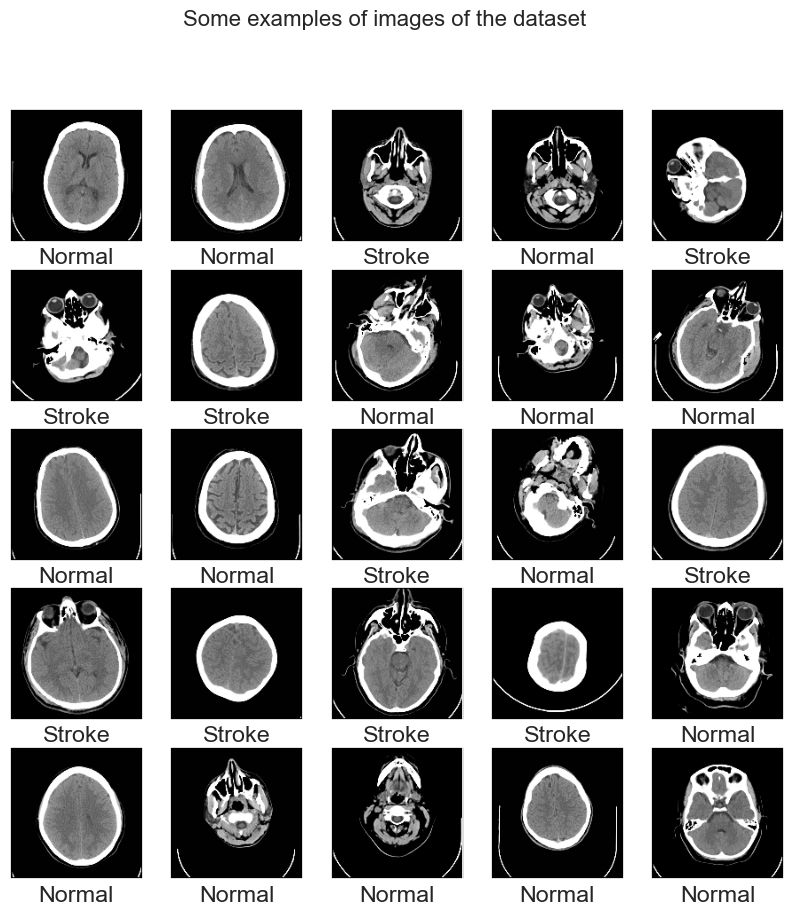

In [15]:
display_examples(class_names, train_images, train_labels)

# CNN

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(2, activation=tf.nn.softmax)
])

In [17]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(train_images, train_labels, batch_size=128, epochs=10, validation_split = 0.2)

Epoch 1/10
16/16 [==============================] - 66s 4s/step - loss: 1.6558 - accuracy: 0.4570 - val_loss: 0.6895 - val_accuracy: 0.6986
Epoch 2/10
16/16 [==============================] - 54s 3s/step - loss: 0.6896 - accuracy: 0.6430 - val_loss: 0.6861 - val_accuracy: 0.7066
Epoch 3/10
16/16 [==============================] - 51s 3s/step - loss: 0.6824 - accuracy: 0.7000 - val_loss: 0.6762 - val_accuracy: 0.6826
Epoch 4/10
16/16 [==============================] - 48s 3s/step - loss: 0.6611 - accuracy: 0.7095 - val_loss: 0.6433 - val_accuracy: 0.7864
Epoch 5/10
16/16 [==============================] - 40s 2s/step - loss: 0.6148 - accuracy: 0.7710 - val_loss: 0.5967 - val_accuracy: 0.7565
Epoch 6/10
16/16 [==============================] - 38s 2s/step - loss: 0.5558 - accuracy: 0.8280 - val_loss: 0.5462 - val_accuracy: 0.8263
Epoch 7/10
16/16 [==============================] - 37s 2s/step - loss: 0.5027 - accuracy: 0.8735 - val_loss: 0.5093 - val_accuracy: 0.9082
Epoch 8/10
16/16 [==

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import numpy as np

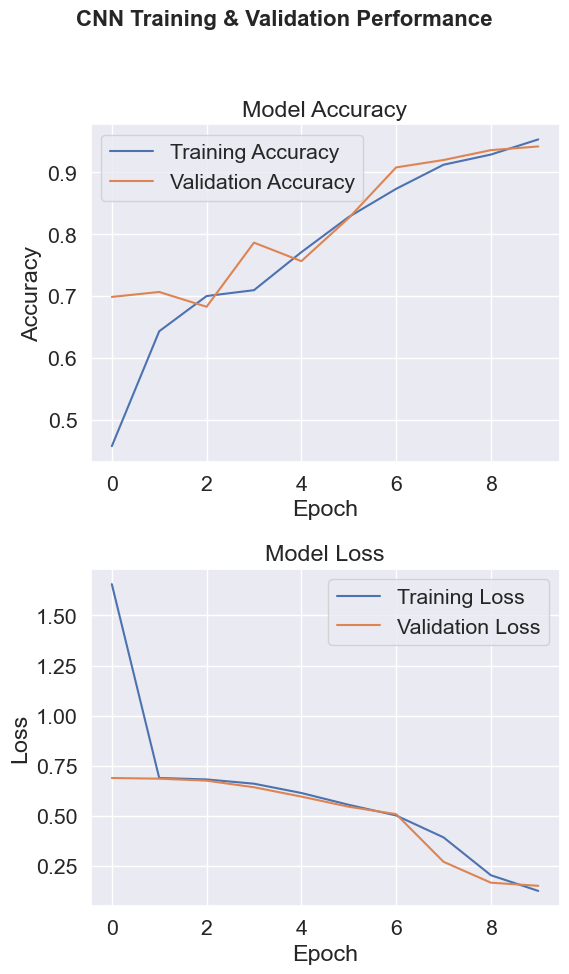

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(6,10))

# Accuracy plot
axs[0].plot(history.history['accuracy'], label='Training Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend()

# Loss plot
axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_title('Model Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend()


fig.suptitle("CNN Training & Validation Performance", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # adjust so title fits
plt.show()


In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test Accuracy: {test_acc:.4f}')


38/38 [==============================] - 5s 130ms/step - loss: 0.1111 - accuracy: 0.9513
Test Accuracy: 0.9513


In [22]:
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels


38/38 [==============================] - 5s 122ms/step


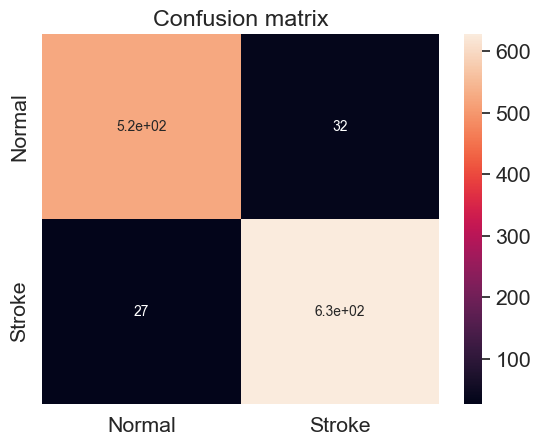

In [23]:
cm = confusion_matrix(test_labels, y_pred)
ax = plt.axes()
sn.heatmap(cm, annot=True,
           annot_kws={"size": 10},
           xticklabels=class_names,
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()

In [24]:
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")


Sensitivity (Recall): 0.9588
Specificity: 0.9424
Precision: 0.9515
F1 Score: 0.9551


In [25]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       556
           1       0.95      0.96      0.96       655

    accuracy                           0.95      1211
   macro avg       0.95      0.95      0.95      1211
weighted avg       0.95      0.95      0.95      1211



# **ResNet101**

In [26]:
# Imports
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet101 model without top layers
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze the base model

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

# Define the full model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, batch_size=32, epochs=10, validation_split=0.2)


171446536/171446536 [==============================] - 64s 0us/step
Epoch 1/10
63/63 [==============================] - 161s 2s/step - loss: 0.6656 - accuracy: 0.6130 - val_loss: 0.7037 - val_accuracy: 0.5130
Epoch 2/10
63/63 [==============================] - 158s 3s/step - loss: 0.6176 - accuracy: 0.6610 - val_loss: 0.5880 - val_accuracy: 0.7206
Epoch 3/10
63/63 [==============================] - 147s 2s/step - loss: 0.5876 - accuracy: 0.6850 - val_loss: 0.5478 - val_accuracy: 0.7146
Epoch 4/10
63/63 [==============================] - 140s 2s/step - loss: 0.5843 - accuracy: 0.6980 - val_loss: 0.5405 - val_accuracy: 0.7126
Epoch 5/10
63/63 [==============================] - 151s 2s/step - loss: 0.5447 - accuracy: 0.7225 - val_loss: 0.5361 - val_accuracy: 0.7026
Epoch 6/10
63/63 [==============================] - 152s 2s/step - loss: 0.5355 - accuracy: 0.7270 - val_loss: 0.5053 - val_accuracy: 0.7585
Epoch 7/10
63/63 [==============================] - 146s 2s/step - loss: 0.5096 - accu

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import numpy as np

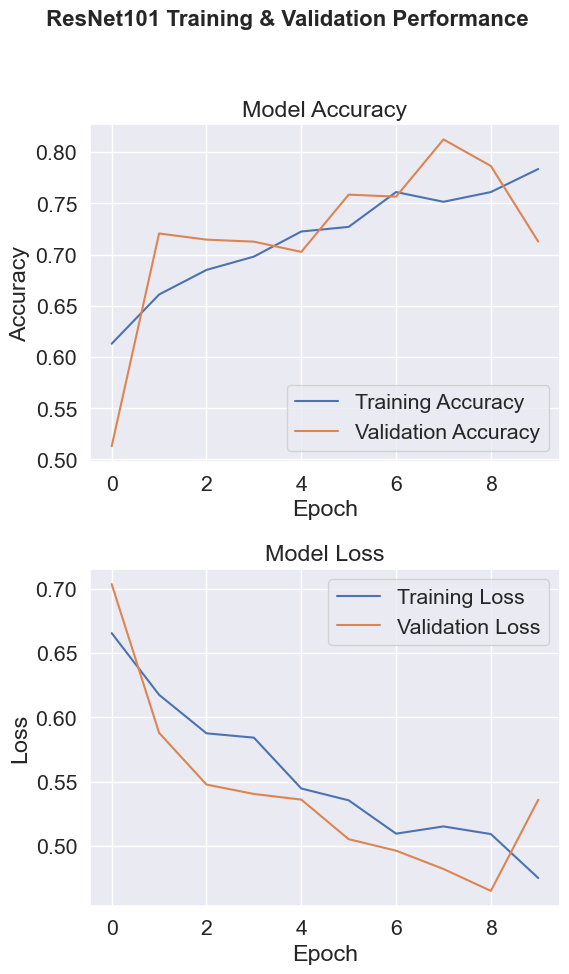

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(6,10))

# Accuracy plot
axs[0].plot(history.history['accuracy'], label='Training Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend()

# Loss plot
axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_title('Model Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend()


fig.suptitle(" ResNet101 Training & Validation Performance", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


In [29]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test Accuracy : {test_acc:.4f}')


38/38 [==============================] - 71s 2s/step - loss: 0.4515 - accuracy: 0.7803
Test Accuracy : 0.7803


In [30]:
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels


38/38 [==============================] - 77s 2s/step


In [31]:
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")


Sensitivity (Recall): 0.9588
Specificity: 0.9424
Precision: 0.9515
F1 Score: 0.9551


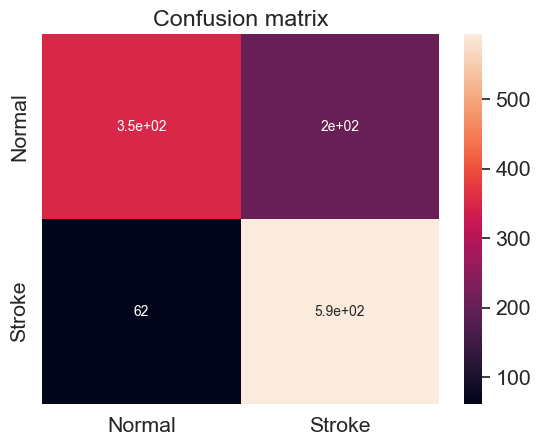

In [32]:
CM = confusion_matrix(test_labels, y_pred)
ax = plt.axes()
sn.heatmap(CM, annot=True,
           annot_kws={"size": 10},
           xticklabels=class_names,
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()

In [33]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.63      0.73       556
           1       0.74      0.91      0.82       655

    accuracy                           0.78      1211
   macro avg       0.80      0.77      0.77      1211
weighted avg       0.79      0.78      0.78      1211



# **VGG19**

In [34]:
from tensorflow.keras.applications import VGG19

base_model = VGG19(weights='imagenet', include_top=False, input_shape=(150,150, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, batch_size=32, epochs=10, validation_split=0.2)


80134624/80134624 [==============================] - 30s 0us/step
Epoch 1/10
63/63 [==============================] - 199s 3s/step - loss: 0.6856 - accuracy: 0.5925 - val_loss: 0.6752 - val_accuracy: 0.5768
Epoch 2/10
63/63 [==============================] - 196s 3s/step - loss: 0.6395 - accuracy: 0.6200 - val_loss: 0.6305 - val_accuracy: 0.6547
Epoch 3/10
63/63 [==============================] - 197s 3s/step - loss: 0.6189 - accuracy: 0.6475 - val_loss: 0.6015 - val_accuracy: 0.6986
Epoch 4/10
63/63 [==============================] - 196s 3s/step - loss: 0.5992 - accuracy: 0.6765 - val_loss: 0.5874 - val_accuracy: 0.6866
Epoch 5/10
63/63 [==============================] - 440s 7s/step - loss: 0.5728 - accuracy: 0.6950 - val_loss: 0.5709 - val_accuracy: 0.7226
Epoch 6/10
63/63 [==============================] - 218s 3s/step - loss: 0.5598 - accuracy: 0.7050 - val_loss: 0.5759 - val_accuracy: 0.6766
Epoch 7/10
63/63 [==============================] - 209s 3s/step - loss: 0.5465 - accura

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import numpy as np

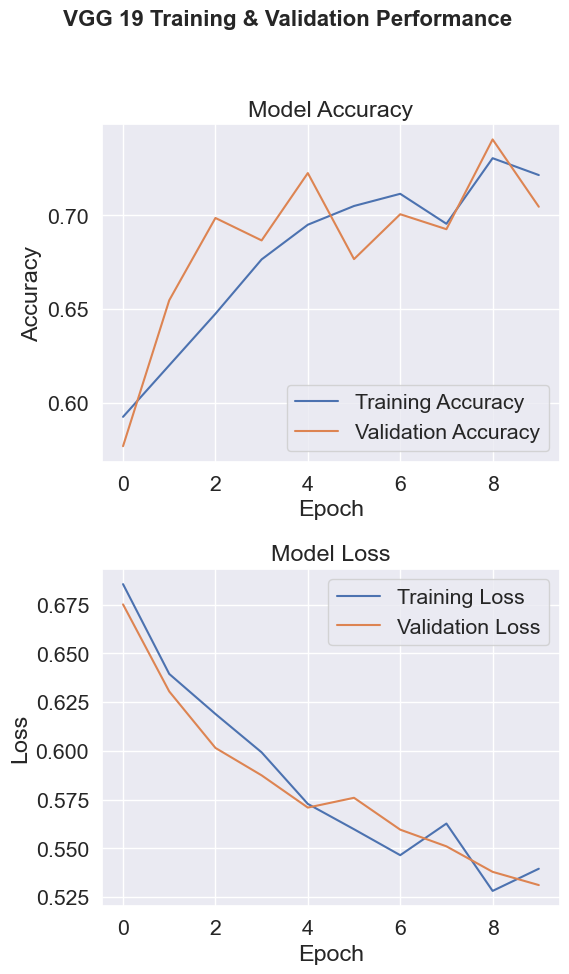

In [36]:
fig, axs = plt.subplots(2, 1, figsize=(6,10))

# Accuracy plot
axs[0].plot(history.history['accuracy'], label='Training Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend()

# Loss plot
axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_title('Model Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend()


fig.suptitle(" VGG 19 Training & Validation Performance", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


In [37]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test Accuracy : {test_acc:.4f}')


38/38 [==============================] - 102s 3s/step - loss: 0.5495 - accuracy: 0.7159
Test Accuracy : 0.7159


In [38]:
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels


38/38 [==============================] - 149s 4s/step


In [39]:
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")


Sensitivity (Recall): 0.9588
Specificity: 0.9424
Precision: 0.9515
F1 Score: 0.9551


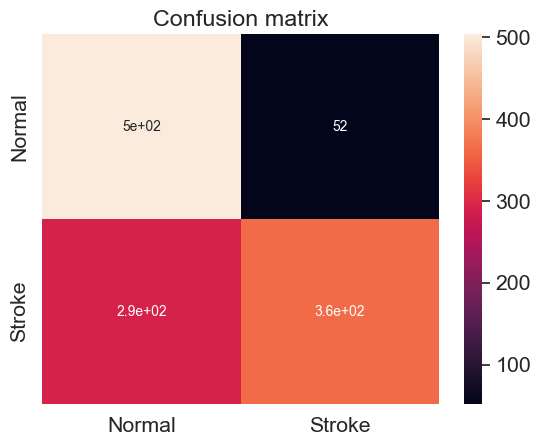

In [40]:
CM = confusion_matrix(test_labels, y_pred)
ax = plt.axes()
sn.heatmap(CM, annot=True,
           annot_kws={"size": 10},
           xticklabels=class_names,
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()

In [41]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.91      0.75       556
           1       0.87      0.55      0.68       655

    accuracy                           0.72      1211
   macro avg       0.75      0.73      0.71      1211
weighted avg       0.76      0.72      0.71      1211



# **saved pre-trained model**

In [42]:
model.save_weights("model_dense.weights.h5")
print("Saved model to disk")

Saved model to disk


In [43]:
model_json=model.to_json()
with open("model_dense.json", "w") as json_file:
    json_file.write(model_json)